# Simulated Dataset

project/src/data_generator.py

In [ ]:
import os

os.makedirs("project/data", exist_ok=True)
os.makedirs("project/src", exist_ok=True)
os.makedirs("project/outputs", exist_ok=True)

print("Folders created ✅")

Folders created ✅


In [ ]:
code = """
import csv
import random
from datetime import datetime, timedelta
import os

OUTPUT_FILE = "project/data/signals.csv"

def generate_dataset(rows=1000):
    os.makedirs("project/data", exist_ok=True)

    start_time = datetime.now()

    with open(OUTPUT_FILE, "w", newline="") as file:
        writer = csv.writer(file)

        writer.writerow([
            "timestamp", "unit_id", "signal_strength",
            "battery_level", "speed", "temperature",
            "packet_loss", "mission_status"
        ])

        for i in range(rows):
            timestamp = start_time + timedelta(seconds=i)

            writer.writerow([
                timestamp.strftime("%Y-%m-%d %H:%M:%S"),
                f"U{random.randint(1,10)}",
                random.randint(10, 100),
                random.randint(5, 100),
                random.randint(0, 150),
                random.randint(20, 100),
                random.randint(0, 30),
                random.choice(["ACTIVE", "IDLE", "RETURNING", "ERROR"])
            ])

    print("Dataset created ✅")

if __name__ == "__main__":
    generate_dataset()
"""

import os
os.makedirs("project/src", exist_ok=True)

with open("project/src/data_generator.py", "w") as f:
    f.write(code)

print("data_generator.py created ✅")

data_generator.py created ✅


In [ ]:
!python project/src/data_generator.py

Dataset created ✅


In [ ]:
import os
print(os.listdir("project/data"))

['signals.csv']


# Anomaly Detection

anomaly_detector.py

In [ ]:
code = """
def detect_anomalies(data):
    alerts = []

    if data["battery_level"] < 20:
        alerts.append({"alert": "Low Battery", "reason": "Battery level below 20%"})

    if data["signal_strength"] < 30:
        alerts.append({"alert": "Weak Signal", "reason": "Signal strength below threshold"})

    if data["packet_loss"] > 20:
        alerts.append({"alert": "High Packet Loss", "reason": "Packet loss above 20%"})

    if data["temperature"] > 80:
        alerts.append({"alert": "Overheating", "reason": "Temperature exceeds safe limit"})

    if data["speed"] > 100:
        alerts.append({"alert": "Unusual Speed", "reason": "Speed exceeds normal range"})

    return alerts
"""

with open("project/src/anomaly_detector.py", "w") as f:
    f.write(code)

print("anomaly_detector.py created ✅")

anomaly_detector.py created ✅


# Risk Scoring and Decision Output

risk_engine.py.

In [ ]:
code = """
import uuid

ALERT_SCORES = {
    "Low Battery": 30,
    "Weak Signal": 20,
    "High Packet Loss": 25,
    "Overheating": 30,
    "Unusual Speed": 25
}

def calculate_risk(alerts):
    score = 0
    reasons = []

    for alert in alerts:
        score += ALERT_SCORES.get(alert["alert"], 0)
        reasons.append(alert["reason"])

    return score, reasons


def classify_status(score):
    if score == 0:
        return "Normal"
    elif score <= 30:
        return "Warning"
    elif score <= 60:
        return "High Risk"
    else:
        return "Critical"


def get_action(status):
    if status == "Normal":
        return "No action required"
    elif status == "Warning":
        return "Monitor and review"
    elif status == "High Risk":
        return "Inspect and take corrective action"
    else:
        return "Escalate for human review"


def generate_output(data, alerts):
    score, reasons = calculate_risk(alerts)
    status = classify_status(score)

    return {
        "trace_id": str(uuid.uuid4()),
        "unit_id": data["unit_id"],
        "risk_score": score,
        "status": status,
        "reasons": reasons,
        "recommended_action": get_action(status)
    }
"""

with open("project/src/risk_engine.py", "w") as f:
    f.write(code)

print("risk_engine.py created ✅")

risk_engine.py created ✅


# stream_simulator.py

In [ ]:
code = """
import csv
import time
import json

from anomaly_detector import detect_anomalies
from risk_engine import generate_output

DATA_FILE = "project/data/signals.csv"
LOG_FILE = "project/outputs/logs.jsonl"

def stream_data():
    print("Streaming started...\\n")

    with open(DATA_FILE) as file:
        reader = csv.DictReader(file)

        for row in reader:
            data = {
                "timestamp": row["timestamp"],
                "unit_id": row["unit_id"],
                "signal_strength": int(row["signal_strength"]),
                "battery_level": int(row["battery_level"]),
                "speed": int(row["speed"]),
                "temperature": int(row["temperature"]),
                "packet_loss": int(row["packet_loss"]),
                "mission_status": row["mission_status"]
            }

            alerts = detect_anomalies(data)
            result = generate_output(data, alerts)

            # 🔥 Save logs (VERY IMPORTANT for replay)
            log_entry = {
                "timestamp": data["timestamp"],
                "unit_id": data["unit_id"],
                "alerts": alerts,
                "result": result
            }

            with open(LOG_FILE, "a") as f:
                f.write(json.dumps(log_entry) + "\\n")

            print(result)
            time.sleep(0.2)

if __name__ == "__main__":
    stream_data()
"""

with open("project/src/stream_simulator.py", "w") as f:
    f.write(code)

print("stream_simulator.py created ✅")

stream_simulator.py created ✅


In [ ]:
code = """
import sys
sys.path.append("project/src")

from data_generator import generate_data
from stream_simulator import stream_data

if __name__ == "__main__":
    print("Starting system...")

    generate_data()
    stream_data()

    print("System finished ✅")
"""

import os
os.makedirs("project/src", exist_ok=True)

with open("project/src/main.py", "w") as f:
    f.write(code)

print("main.py created ✅")

main.py created ✅


In [ ]:
import os
print(os.listdir("project/src"))

['anomaly_detector.py', 'data_generator.py', 'stream_simulator.py', 'risk_engine.py', 'main.py']


In [ ]:
from google.colab import files

files.download("project/src/data_generator.py")
files.download("project/src/anomaly_detector.py")
files.download("project/src/risk_engine.py")
files.download("project/src/stream_simulator.py")
files.download("project/src/main.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python project/src/stream_simulator.py

Streaming started...

{'trace_id': '7f27dfa7-6ce3-414c-ae22-a344cc8a9cb8', 'unit_id': 'U5', 'risk_score': 0, 'status': 'Normal', 'reasons': [], 'recommended_action': 'No action required'}
{'trace_id': '80e2c774-084b-4124-bcf7-daaa93a145c7', 'unit_id': 'U5', 'risk_score': 25, 'status': 'Warning', 'reasons': ['Speed exceeds normal range'], 'recommended_action': 'Monitor and review'}
{'trace_id': '89a06969-a89d-4c3a-8f24-b3557d37acf0', 'unit_id': 'U9', 'risk_score': 25, 'status': 'Warning', 'reasons': ['Speed exceeds normal range'], 'recommended_action': 'Monitor and review'}
{'trace_id': 'defeb8be-5af4-4d71-9cd6-5485c8cbcbb7', 'unit_id': 'U7', 'risk_score': 70, 'status': 'Critical', 'reasons': ['Signal strength below threshold', 'Packet loss above 20%', 'Speed exceeds normal range'], 'recommended_action': 'Escalate for human review'}
{'trace_id': 'a422f142-d8e2-499e-bce4-c4202d6dc90b', 'unit_id': 'U6', 'risk_score': 0, 'status': 'Normal', 'reasons': [], 'recommended_action': 'No action r

# Replay Engine

replay_engine.py

In [ ]:
code = """
import json
from datetime import datetime

LOG_FILE = "project/outputs/logs.jsonl"

def replay(unit_id=None, alert_type=None, start_time=None, end_time=None):
    print("\\nReplaying logs...\\n")

    try:
        with open(LOG_FILE, "r") as file:
            for line in file:
                record = json.loads(line)

                timestamp = record["timestamp"]
                uid = record["unit_id"]
                alerts = record["alerts"]
                result = record["result"]

                # Filter: unit_id
                if unit_id and uid != unit_id:
                    continue

                # Filter: alert_type
                if alert_type:
                    if not any(alert_type in a["alert"] for a in alerts):
                        continue

                # Filter: time range
                if start_time or end_time:
                    t = datetime.strptime(timestamp, "%Y-%m-%d %H:%M:%S")

                    if start_time and t < datetime.strptime(start_time, "%Y-%m-%d %H:%M:%S"):
                        continue

                    if end_time and t > datetime.strptime(end_time, "%Y-%m-%d %H:%M:%S"):
                        continue

                print({
                    "timestamp": timestamp,
                    "unit_id": uid,
                    "status": result["status"],
                    "risk_score": result["risk_score"],
                    "reasons": result["reasons"]
                })

    except FileNotFoundError:
        print("Run streaming first to generate logs.")

if __name__ == "__main__":
    replay()
"""

with open("project/src/replay_engine.py", "w") as f:
    f.write(code)

print("replay_engine.py created ✅")

replay_engine.py created ✅


In [ ]:
files.download("project/outputs/logs.jsonl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("project/src/replay_engine.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python project/src/replay_engine.py


Replaying logs...

{'timestamp': '2026-05-01 19:41:30', 'unit_id': 'U5', 'status': 'Normal', 'risk_score': 0, 'reasons': []}
{'timestamp': '2026-05-01 19:41:31', 'unit_id': 'U5', 'status': 'Warning', 'risk_score': 25, 'reasons': ['Speed exceeds normal range']}
{'timestamp': '2026-05-01 19:41:32', 'unit_id': 'U9', 'status': 'Warning', 'risk_score': 25, 'reasons': ['Speed exceeds normal range']}
{'timestamp': '2026-05-01 19:41:33', 'unit_id': 'U7', 'status': 'Critical', 'risk_score': 70, 'reasons': ['Signal strength below threshold', 'Packet loss above 20%', 'Speed exceeds normal range']}
{'timestamp': '2026-05-01 19:41:34', 'unit_id': 'U6', 'status': 'Normal', 'risk_score': 0, 'reasons': []}
{'timestamp': '2026-05-01 19:41:35', 'unit_id': 'U1', 'status': 'Warning', 'risk_score': 25, 'reasons': ['Packet loss above 20%']}
{'timestamp': '2026-05-01 19:41:36', 'unit_id': 'U4', 'status': 'Warning', 'risk_score': 25, 'reasons': ['Packet loss above 20%']}
{'timestamp': '2026-05-01 19:41:37', 

# Visualization

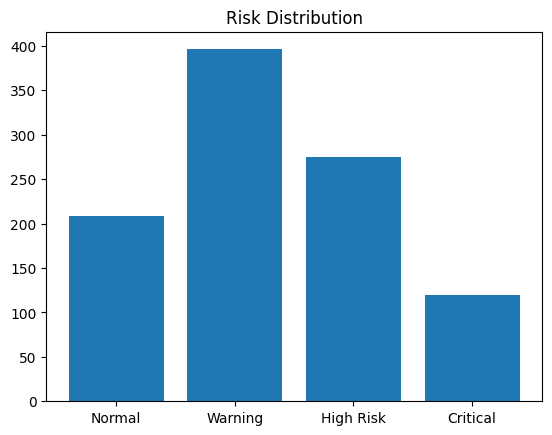

In [ ]:
import json
import matplotlib.pyplot as plt

counts = {"Normal":0, "Warning":0, "High Risk":0, "Critical":0}

with open("project/outputs/logs.jsonl") as f:
    for line in f:
        status = json.loads(line)["result"]["status"]
        counts[status] += 1

plt.bar(counts.keys(), counts.values())
plt.title("Risk Distribution")
plt.show()

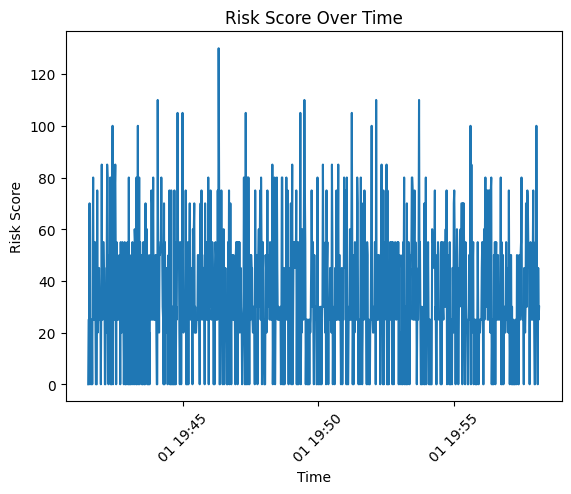

In [ ]:
import json
from datetime import datetime
import matplotlib.pyplot as plt

timestamps = []
scores = []

with open("project/outputs/logs.jsonl") as f:
    for line in f:
        record = json.loads(line)
        timestamps.append(datetime.strptime(record["timestamp"], "%Y-%m-%d %H:%M:%S"))
        scores.append(record["result"]["risk_score"])

plt.plot(timestamps, scores)
plt.title("Risk Score Over Time")
plt.xlabel("Time")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

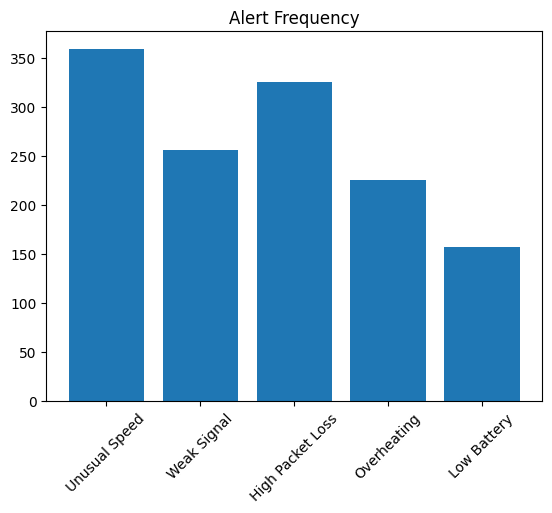

In [ ]:
import json
from collections import Counter
import matplotlib.pyplot as plt

alerts = []

with open("project/outputs/logs.jsonl") as f:
    for line in f:
        record = json.loads(line)
        for a in record["alerts"]:
            alerts.append(a["alert"])

count = Counter(alerts)

plt.bar(count.keys(), count.values())
plt.title("Alert Frequency")
plt.xticks(rotation=45)
plt.show()

# Streamlit Dashboard

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 129.4 MB/s eta 0:00:00


In [ ]:
!mkdir -p project/dashboard

In [ ]:
!ls project/dashboard

In [ ]:
!ls project/outputs

logs.jsonl


In [ ]:
%%writefile project/dashboard/app.py
import streamlit as st
import pandas as pd
import json
import os

LOG_FILE = "project/outputs/logs.jsonl"

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="Signal Intelligence Dashboard",
    layout="wide"
)

# -----------------------------
# TITLE
# -----------------------------
st.title("📡 Real-Time Signal Intelligence Monitoring Dashboard")
st.caption("Real-time signal analysis with risk scoring and replay insights")

# -----------------------------
# LOAD DATA
# -----------------------------
@st.cache_data
def load_logs():
    if not os.path.exists(LOG_FILE):
        return pd.DataFrame()

    data = []
    with open(LOG_FILE, "r") as f:
        for line in f:
            r = json.loads(line)
            data.append({
                "timestamp": r["timestamp"],
                "unit_id": r["unit_id"],
                "status": r["result"]["status"],
                "risk_score": r["result"]["risk_score"],
                "reasons": ", ".join(r["result"]["reasons"])
            })
    return pd.DataFrame(data)

df = load_logs()

# -----------------------------
# NO DATA HANDLING
# -----------------------------
if df.empty:
    st.warning("⚠ No logs found. Run streaming first.")
    st.stop()

# -----------------------------
# SIDEBAR FILTERS
# -----------------------------
st.sidebar.header("🔍 Filters")

unit_filter = st.sidebar.selectbox(
    "Select Unit",
    ["All"] + sorted(df["unit_id"].unique().tolist())
)

status_filter = st.sidebar.selectbox(
    "Select Status",
    ["All", "Normal", "Warning", "High Risk", "Critical"]
)

# Apply filters
if unit_filter != "All":
    df = df[df["unit_id"] == unit_filter]

if status_filter != "All":
    df = df[df["status"] == status_filter]

# -----------------------------
# METRICS
# -----------------------------
col1, col2, col3, col4, col5 = st.columns(5)

col1.metric("Total Signals", len(df))
col2.metric("Normal", (df["status"] == "Normal").sum())
col3.metric("Warning", (df["status"] == "Warning").sum())
col4.metric("High Risk", (df["status"] == "High Risk").sum())
col5.metric("Critical", (df["status"] == "Critical").sum())

st.divider()

# -----------------------------
# TABLE
# -----------------------------
st.subheader("📋 Signal Logs")
st.dataframe(df, use_container_width=True)

# -----------------------------
# CHARTS
# -----------------------------
colA, colB = st.columns(2)

with colA:
    st.subheader("📊 Risk Distribution")
    st.bar_chart(df["status"].value_counts())

with colB:
    st.subheader("📈 Risk Score Trend")
    st.line_chart(df["risk_score"])

Writing project/dashboard/app.py


In [ ]:
files.download("project/dashboard/app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!streamlit run project/dashboard/app.py & npx cloudflared tunnel --url http://localhost:8501

⠙⠹⠸⠼⠴⠦⠧

2026-05-01T19:46:37Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-01T19:46:37Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-01 19:46:39.045 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.103.177:8501

2026-05-01T19:46:42Z INF +-------------------------------------------------

# Sample Output Section

In [ ]:
{
  "timestamp": "2026-05-02T10:15:30",
  "event_id": 1024,
  "anomaly_score": 0.87,
  "risk_level": "HIGH",
  "status": "FLAGGED"
}

In [ ]:
python tests/test_anomaly.py
python tests/test_risk_engine.py